In [ ]:
pip install "gymnasium[classic-control]" stable-baselines3 sb3-contrib pyyaml pydantic

In [ ]:
pip uninstall -y torch torchvision torchaudio torchdata torchtext dgl

In [ ]:
pip install torch==2.1.2 

In [ ]:
pip install torchdata==0.7.1

In [ ]:
pip install dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html

In [ ]:
pip install "numpy<2.0.0"

In [ ]:
pip install holidays

In [1]:
from typing import Optional
import datetime
import json
import numpy as np
import pandas as pd
import gymnasium as gym
from pathlib import Path

ACTION_TO_SHIFT_TEAM = {1: ("M", "A"), 2: ("T", "A"), 3: ("M", "B"), 4: ("T", "B")}
ACTION_SHIFT_ORDER = {0: 0, 1: 1, 2: 2, 3: 1, 4: 2}


def _build_special_days(year, n_days):
    import holidays as hl
    pt_holidays = hl.country_holidays("PT", years=[year])
    start = datetime.date(year, 1, 1)
    special = set()
    for d in range(n_days):
        date = start + datetime.timedelta(days=d)
        if date.weekday() == 6 or date in pt_holidays:
            special.add(d)
    return special


class ScheduleEnv(gym.Env):
    NUM_ACTIONS = 5

    def __init__(self, data_dir: str = "../../../../data/problems/SMARTASK_SIMPLE_2025"):
        super().__init__()
        base = Path(data_dir)

        with open(base / "problem.json") as f:
            prob = json.load(f)

        self.num_days = prob["temporalScope"]["numDays"]
        self.year = prob["temporalScope"]["year"]
        employees = prob["employees"]["simple"]
        self.num_employees = len(employees)
        self.employee_teams = [set(emp.get("teams", [])) for emp in employees]

        self.dual_team = [len(teams) > 1 for teams in self.employee_teams]
        self.team_sizes = {
            "A": sum(1 for teams in self.employee_teams if "A" in teams),
            "B": sum(1 for teams in self.employee_teams if "B" in teams),
        }

        vac_df = pd.read_csv(base / "vacations.csv", header=None)
        self.vac_mask = vac_df.iloc[:, 1:].values.astype(bool)

        dem_df = pd.read_csv(base / "demand.csv")
        dem_df["date"] = pd.to_datetime(dem_df["date"])
        start_ts = pd.Timestamp(f"{self.year}-01-01")
        dem_df["day_idx"] = (dem_df["date"] - start_ts).dt.days

        self.min_demand = np.zeros((self.num_days, 2, 2), dtype=int)
        self.ideal_demand = np.zeros((self.num_days, 2, 2), dtype=int)
        _shift_idx = {"M": 0, "T": 1}
        _team_idx = {"A": 0, "B": 1}
        for _, row in dem_df.iterrows():
            d = int(row["day_idx"])
            s = _shift_idx[row["shift"]]
            t = _team_idx[row["team"]]
            self.min_demand[d, s, t] = int(row["minimum"])
            self.ideal_demand[d, s, t] = int(row["ideal"])

        self.special_days = _build_special_days(self.year, self.num_days)

        self.max_days_per_year = 223
        self.max_consecutive_days = 5
        self.special_days_cap = 22

        self.total_steps = self.num_employees * self.num_days
        self.num_features = 2

        self.observation_space = gym.spaces.Box(
            low=-1.0, high=10.0,
            shape=(self.total_steps, self.num_features + self.NUM_ACTIONS),
            dtype=np.float32,
        )
        self.action_space = gym.spaces.Discrete(self.NUM_ACTIONS)
        self.reset()

    def _build_initial_matrix(self):
        matrix = np.zeros(
            (self.total_steps, self.num_features + self.NUM_ACTIONS), dtype=np.float32
        )
        self.emp_day_to_row = {}
        row = 0
        for day in self.day_order:
            for emp in range(self.num_employees):
                matrix[row, 0] = emp
                matrix[row, 1] = day
                self.emp_day_to_row[(emp, day)] = row
                row += 1
        return matrix

    def _row(self, emp, day):
        return self.emp_day_to_row[(emp, day)]

    def _is_working(self, emp, day):
        row = self.emp_day_to_row[(emp, day)]
        slot = self.state[row, 2:]
        return slot.sum() > 0 and slot[0] != 1

    def _get_assigned_shift(self, emp, day):
        row = self.emp_day_to_row[(emp, day)]
        slot = self.state[row, 2:]
        if slot.sum() == 0 or slot[0] == 1:
            return None
        for a in range(1, self.NUM_ACTIONS):
            if slot[a] == 1:
                return ACTION_TO_SHIFT_TEAM[a][0]
        return None

    def _get_prev_shift(self, emp, day):
        if day == 0:
            return None
        return self._get_assigned_shift(emp, day - 1)

    def _get_next_shift(self, emp, day):
        if day >= self.num_days - 1:
            return None
        return self._get_assigned_shift(emp, day + 1)

    def _consecutive_streak_if_work(self, emp, day):
        streak = 1
        d = day - 1
        while d >= 0 and self._is_working(emp, d):
            streak += 1
            d -= 1
        d = day + 1
        while d < self.num_days and self._is_working(emp, d):
            streak += 1
            d += 1
        return streak

    def _get_info(self):
        return {}

    def current_emp_day(self):
        if self.phase == 1:
            return int(self.state[self.current_step, 0]), int(self.state[self.current_step, 1])
        else:
            return self.phase2_steps[self.phase2_idx]

    def _calculate_reward_phase1(self, emp_id, day_id, action):
        reward = 0.0

        if action != 0:
            _, team = ACTION_TO_SHIFT_TEAM[action]

            if self.dual_team[emp_id]:
                team_a_size = self.team_sizes["A"]
                team_b_size = self.team_sizes["B"]
                if team_a_size != team_b_size:
                    smaller_team = "A" if team_a_size < team_b_size else "B"
                    if team == smaller_team:
                        reward += abs(team_a_size - team_b_size) * 0.5

        is_last_emp_today = (
            self.current_step >= self.total_steps or
            int(self.state[self.current_step, 1]) != day_id
        )
        if is_last_emp_today:
            day_shortfall = np.maximum(0, self.min_demand[day_id] - self.daily_coverage[day_id]).sum()
            if day_shortfall == 0:
                reward += 3.0
            else:
                reward -= day_shortfall * 2.0

        return reward

    def _calculate_reward_phase2(self, emp_id, day_id, action):
        reward = 0.0
        day_has_shortfall = np.any(
            self.daily_coverage[day_id] < self.min_demand[day_id]
        )

        if action != 0:
            shift, team = ACTION_TO_SHIFT_TEAM[action]
            s = 0 if shift == "M" else 1
            t = 0 if team  == "A" else 1
            cov = self.daily_coverage[day_id, s, t]
            mn = self.min_demand[day_id, s, t]

            ideal = self.ideal_demand[day_id, s, t]
            if cov <= mn:
                reward += 3.0  # Filling a minimum shortfall gap
            elif cov <= ideal:
                reward += 1.5  # Filling toward the ideal staffing level
            else:
                reward += 1.0  # Above ideal, still working toward 223

            if self.dual_team[emp_id]:
                team_a_size = self.team_sizes["A"]
                team_b_size = self.team_sizes["B"]
                if team_a_size != team_b_size:
                    smaller_team = "A" if team_a_size < team_b_size else "B"
                    if team == smaller_team:
                        reward += abs(team_a_size - team_b_size) * 0.5
        else:
            if day_has_shortfall:
                reward -= 0.5 # Resting on a shortfall day
            else:
                reward -= 0.1 # Resting on non-shortfall day

        return reward

    def _calculate_final_reward(self):
        reward = 0.0
        total_shortfall = 0
        for day in range(self.num_days):
            for s in range(2):
                for t in range(2):
                    shortfall = self.min_demand[day, s, t] - self.daily_coverage[day, s, t]
                    if shortfall > 0:
                        total_shortfall += shortfall
        reward -= total_shortfall * 20.0

        if total_shortfall == 0:
            reward += 500.0

        total_ideal_gap = 0
        for day in range(self.num_days):
            for s in range(2):
                for t in range(2):
                    gap = self.ideal_demand[day, s, t] - self.daily_coverage[day, s, t]
                    if gap > 0:
                        total_ideal_gap += gap
        self.ideal_shortfall = int(total_ideal_gap)
        reward -= total_ideal_gap * 2.0

        # Penalize distance from 223 target (secondary goal)
        for emp in range(self.num_employees):
            deficit = self.max_days_per_year - self.days_worked[emp]
            if deficit > 0:
                reward -= deficit * 1.0

        return reward

    def _build_phase2_steps(self):
        shortfall_steps = []
        fill_steps = []

        for day in range(self.num_days):
            has_gap = False
            for s in range(2):
                for t in range(2):
                    if self.daily_coverage[day, s, t] < self.min_demand[day, s, t]:
                        has_gap = True
                        break
                if has_gap:
                    break

            for emp in range(self.num_employees):
                if self.days_worked[emp] >= self.max_days_per_year:
                    continue
                row = self._row(emp, day)
                slot = self.state[row, 2:]
                if slot[0] != 1:  # not resting
                    continue

                if has_gap:
                    shortfall_steps.append((emp, day))
                else:
                    fill_steps.append((emp, day))

        return shortfall_steps + fill_steps

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.day_order = list(range(self.num_days))
        self.state = self._build_initial_matrix()
        self.current_step = 0
        self.phase = 1
        self.phase2_steps = []
        self.phase2_idx = 0
        self.phase1_shortfall = 0
        self.ideal_shortfall = 0
        self.days_worked = np.zeros(self.num_employees, dtype=int)
        self.special_days_worked = np.zeros(self.num_employees, dtype=int)
        self.daily_coverage = np.zeros((self.num_days, 2, 2), dtype=np.float32)
        return self.state, self._get_info()

    def step(self, action):
        emp_id, day_id = self.current_emp_day()
        row = self._row(emp_id, day_id)

        if self.phase == 1:
            self.state[row, 2 + action] = 1

            if action != 0:
                self.days_worked[emp_id] += 1
                shift, team = ACTION_TO_SHIFT_TEAM[action]
                s = 0 if shift == "M" else 1
                t = 0 if team == "A" else 1
                self.daily_coverage[day_id, s, t] += 1
                if day_id in self.special_days:
                    self.special_days_worked[emp_id] += 1

            self.current_step += 1
            reward = self._calculate_reward_phase1(emp_id, day_id, action)

            if self.current_step >= self.total_steps:
                self.phase1_shortfall = int(
                    np.maximum(0, self.min_demand - self.daily_coverage).sum()
                )
                self.phase = 2
                self.phase2_steps = self._build_phase2_steps()
                self.phase2_idx = 0

                if len(self.phase2_steps) == 0:
                    reward += self._calculate_final_reward()
                    return self.state.copy(), reward, True, False, self._get_info()

                return self.state.copy(), reward, False, False, self._get_info()

            return self.state.copy(), reward, False, False, self._get_info()

        else:
            if action != 0:
                self.state[row, 2] = 0  # clear REST
                self.state[row, 2 + action] = 1

                self.days_worked[emp_id] += 1
                shift, team = ACTION_TO_SHIFT_TEAM[action]
                s = 0 if shift == "M" else 1
                t = 0 if team == "A" else 1
                self.daily_coverage[day_id, s, t] += 1
                if day_id in self.special_days:
                    self.special_days_worked[emp_id] += 1

            self.phase2_idx += 1
            reward = self._calculate_reward_phase2(emp_id, day_id, action)

            terminated = self.phase2_idx >= len(self.phase2_steps)
            if terminated:
                reward += self._calculate_final_reward()

            return self.state.copy(), reward, terminated, False, self._get_info()

    def get_action_mask(self):
        if self.phase == 1 and self.current_step >= self.total_steps:
            return np.array([True, False, False, False, False])
        if self.phase == 2 and self.phase2_idx >= len(self.phase2_steps):
            return np.array([True, False, False, False, False])

        emp, day = self.current_emp_day()
        mask = np.ones(self.NUM_ACTIONS, dtype=bool)

        if self.vac_mask[emp, day]:
            mask[1:] = False
            return mask

        if self.days_worked[emp] >= self.max_days_per_year:
            mask[1:] = False
            return mask

        if self._consecutive_streak_if_work(emp, day) > self.max_consecutive_days:
            mask[1:] = False
            return mask

        if day in self.special_days and self.special_days_worked[emp] >= self.special_days_cap:
            mask[1:] = False
            return mask

        prev_shift = self._get_prev_shift(emp, day)
        if prev_shift == "T":
            mask[1] = False  # M-A
            mask[3] = False  # M-B

        next_shift = self._get_next_shift(emp, day)
        if next_shift == "M":
            mask[2] = False  # T-A
            mask[4] = False  # T-B

        for action, (_, team) in ACTION_TO_SHIFT_TEAM.items():
            if team not in self.employee_teams[emp]:
                mask[action] = False

        if self.phase == 1:
            for action in range(1, self.NUM_ACTIONS):
                if mask[action]:
                    shift, team = ACTION_TO_SHIFT_TEAM[action]
                    s = 0 if shift == "M" else 1
                    t = 0 if team == "A" else 1
                    if self.daily_coverage[day, s, t] >= self.min_demand[day, s, t]:
                        mask[action] = False

        if self.phase == 2:
            day_has_gap = np.any(self.daily_coverage[day] < self.min_demand[day])
            if day_has_gap and np.any(mask[1:]):
                can_fill_gap = False
                for a in range(1, self.NUM_ACTIONS):
                    if mask[a]:
                        shift, team = ACTION_TO_SHIFT_TEAM[a]
                        s = 0 if shift == "M" else 1
                        t = 0 if team == "A" else 1
                        if self.daily_coverage[day, s, t] < self.min_demand[day, s, t]:
                            can_fill_gap = True
                            break
                if can_fill_gap:
                    mask[0] = False  # force work only when they can fill a gap
                    for a in range(1, self.NUM_ACTIONS):
                        if mask[a]:
                            shift, team = ACTION_TO_SHIFT_TEAM[a]
                            s = 0 if shift == "M" else 1
                            t = 0 if team == "A" else 1
                            if self.daily_coverage[day, s, t] >= self.min_demand[day, s, t]:
                                mask[a] = False

        if not np.any(mask):
            mask[0] = True
        return mask

    def render(self):
        labels = {0: "-", 1: "M-A", 2: "T-A", 3: "M-B", 4: "T-B"}
        for emp in range(self.num_employees):
            schedule = []
            for day in range(self.num_days):
                r = self.state[self._row(emp, day), 2:]
                schedule.append(labels[int(np.argmax(r))] if r.sum() > 0 else "-")
            print(f"Employee {emp + 1:2d}: {schedule}")
            

In [2]:
import dgl
import dgl.nn as dglnn
import torch
import numpy as np


def build_graph(env):
    sources = []
    destinations = []
    for emp in range(env.num_employees):
        for day in range(env.num_days):
            sources.append(emp)
            destinations.append(day)

    graph_data = {
        ("employee", "assigned_to", "day"): (torch.tensor(sources), torch.tensor(destinations)),
        ("day", "staffed_by", "employee"): (torch.tensor(destinations), torch.tensor(sources)),
    }
    g = dgl.heterograph(graph_data)
    update_graph_features(g, env)
    return g


def update_graph_features(g, env):
    # Employee features: [days_worked/223, streak/5, in_team_A, in_team_B, emp_position]
    emp_feats = np.zeros((env.num_employees, 5), dtype=np.float32)
    for emp in range(env.num_employees):
        emp_feats[emp, 0] = env.days_worked[emp] / 223.0
        emp_feats[emp, 1] = env._consecutive_streak_if_work(emp, env.current_emp_day()[1]) / 5.0
        emp_feats[emp, 2] = float("A" in env.employee_teams[emp])
        emp_feats[emp, 3] = float("B" in env.employee_teams[emp])
        emp_feats[emp, 4] = emp / env.num_employees

    # Day features: [cov_gap_MA, cov_gap_TA, cov_gap_MB, cov_gap_TB, is_special, day_position]
    day_feats = np.zeros((env.num_days, 6), dtype=np.float32)
    for d in range(env.num_days):
        day_feats[d, 0] = env.min_demand[d, 0, 0] - env.daily_coverage[d, 0, 0]
        day_feats[d, 1] = env.min_demand[d, 1, 0] - env.daily_coverage[d, 1, 0]
        day_feats[d, 2] = env.min_demand[d, 0, 1] - env.daily_coverage[d, 0, 1]
        day_feats[d, 3] = env.min_demand[d, 1, 1] - env.daily_coverage[d, 1, 1]
        day_feats[d, 4] = float(d in env.special_days)
        day_feats[d, 5] = d / env.num_days

    g.nodes["employee"].data["feat"] = torch.tensor(emp_feats, dtype=torch.float32)
    g.nodes["day"].data["feat"] = torch.tensor(day_feats, dtype=torch.float32)


/home/joao/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class GNNActorCritic(nn.Module):
    def __init__(self, emp_in_feats=5, day_in_feats=6, hidden_dim=64,
                 encoded_dim=64, num_actions=5):
        super().__init__()
        self.encoded_dim = encoded_dim

        # Projects node features to common hidden dimension so the same GNN layers can be applied to both types of nodes
        self.emp_proj = nn.Linear(emp_in_feats, hidden_dim)
        self.day_proj = nn.Linear(day_in_feats, hidden_dim)

        # First layer: hetero graph conv with separate SAGEConv for each relation (day->employee and employee->day), using 'mean' aggregation
        self.conv1 = dglnn.HeteroGraphConv({
            'assigned_to': dglnn.SAGEConv(hidden_dim, hidden_dim, 'mean'),
            'staffed_by': dglnn.SAGEConv(hidden_dim, hidden_dim, 'mean'),
        }, aggregate='sum')

        # Second layer: hetero graph conv with separate SAGEConv for each relation (allows for employees to learn from other employees assigned to the same day, and for days to learn from other days staffed by the same employee)
        self.conv2 = dglnn.HeteroGraphConv({
            'assigned_to': dglnn.SAGEConv(hidden_dim, encoded_dim, 'mean'),
            'staffed_by': dglnn.SAGEConv(hidden_dim, encoded_dim, 'mean'),
        }, aggregate='sum')

        # Head input: emp_emb + day_emb + live_cov_gap(4) + dyn_feats(2) + phase(1)
        head_in = encoded_dim * 2 + 4 + 2 + 1

        # Separate heads taking the combined features as input
        self.actor_head = nn.Sequential(
            nn.Linear(head_in, 64),
            nn.Tanh(),
            nn.Linear(64, num_actions),
        )
        self.critic_head = nn.Sequential(
            nn.Linear(head_in, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def gnn_forward(self, g):
        # Initial projection of node features to hidden dimension
        h = {
            "employee": self.emp_proj(g.nodes["employee"].data["feat"]),
            "day": self.day_proj(g.nodes["day"].data["feat"]),
        }
        # First layer with ReLU
        h = self.conv1(g, h)
        h = {k: F.relu(v) for k, v in h.items()}
        # Second layer with ReLU
        h = self.conv2(g, h)
        h = {k: F.relu(v) for k, v in h.items()}
        # Return: embeddings for all employee and day nodes
        return h["employee"], h["day"]

    def _compute_heads(self, emp_e, day_e, cov_gaps, dyn_feats, action_masks, phase):
        # Normalize dynamic features to [0, 1] range based on known max values (223 for days worked, 5 for consecutive streak)
        norm_dyn = dyn_feats.clone()
        norm_dyn[..., 0] /= 223.0
        norm_dyn[..., 1] /= 5.0
        norm_cov_gaps = cov_gaps / 10.0  # normalise by approximate max team size
        # Combine all features for head input: emp_emb + day_emb + norm_cov_gap(4) + norm_dyn(2) + phase(1)
        combined = torch.cat([emp_e, day_e, norm_cov_gaps, norm_dyn, phase], dim=-1)
        # Pass inputs through separate actor and critic heads
        values = self.critic_head(combined).squeeze(-1)
        logits = self.actor_head(combined)
        # Apply action masks to logits: set invalid actions to -inf before softmax
        masks_bool = torch.as_tensor(action_masks, dtype=torch.bool)
        if not masks_bool.any():
            masks_bool[..., 0] = True
        logits = logits.masked_fill(~masks_bool, float("-inf"))
        # Compute action probabilities with masked logits
        probs = F.softmax(logits, dim=-1)
        return probs, values

    def _heads(self, emp_emb, day_emb, emp_ids, day_ids,
              cov_gaps, dyn_feats, action_masks, phase):
        # Choose the relevant employee and day embeddings based on the current emp_ids and day_ids
        e = emp_emb[emp_ids]
        d = day_emb[day_ids]
        return self._compute_heads(e, d, cov_gaps, dyn_feats, action_masks, phase)

    def forward(self, g, emp_ids, day_ids, cov_gaps, dyn_feats, action_masks, phase):
        # Forward pass through GNN to get embeddings for all employees and days, then compute action probabilities and state value for the current emp_ids and day_ids
        emp_emb, day_emb = self.gnn_forward(g)
        return self._heads(emp_emb, day_emb, emp_ids, day_ids,
                          cov_gaps, dyn_feats, action_masks, phase)


In [4]:
from dataclasses import dataclass, field
from torch.distributions import Categorical


@dataclass
class Trajectory:
    emp_ids: list = field(default_factory=list)
    day_ids: list = field(default_factory=list)
    coverage_gaps: list = field(default_factory=list)
    dyn_emp_feats: list = field(default_factory=list)
    action_masks: list = field(default_factory=list)
    phases: list = field(default_factory=list)
    actions: list = field(default_factory=list)
    log_probs_old: list = field(default_factory=list)
    rewards: list = field(default_factory=list)
    values: list = field(default_factory=list)
    # Per-step graph feature snapshots for PPO
    emp_feats_snapshots: list = field(default_factory=list)
    day_feats_snapshots: list = field(default_factory=list)

    def to_tensors(self):
        return {
            "emp_ids": torch.tensor(self.emp_ids, dtype=torch.long),
            "day_ids": torch.tensor(self.day_ids, dtype=torch.long),
            "coverage_gaps": torch.stack(self.coverage_gaps),
            "dyn_emp_feats": torch.stack(self.dyn_emp_feats),
            "action_masks": torch.stack(self.action_masks),
            "phases": torch.stack(self.phases),
            "actions": torch.tensor(self.actions, dtype=torch.long),
            "log_probs_old": torch.tensor(self.log_probs_old, dtype=torch.float32),
            "rewards": torch.tensor(self.rewards, dtype=torch.float32),
            "values": torch.tensor(self.values, dtype=torch.float32),
            "emp_feats": torch.stack(self.emp_feats_snapshots),
            "day_feats": torch.stack(self.day_feats_snapshots),
        }


def _get_consecutive_days(env, emp_id, day_id):
    streak = 0
    d = day_id - 1
    while d >= 0 and env._is_working(emp_id, d):
        streak += 1
        d -= 1
    return streak


def collect_trajectory(env, model, graph):
    model.eval()
    traj = Trajectory()
    env.reset()
    terminated = truncated = False

    cached_day_id = None
    cached_emp_emb = None
    cached_day_emb = None
    cached_emp_feats = None
    cached_day_feats = None

    with torch.no_grad():
        while not (terminated or truncated):
            emp_id, day_id = env.current_emp_day()

            # Recompute GNN embeddings once per day
            if day_id != cached_day_id:
                # Update graph node features with current environment state before GNN forward pass
                update_graph_features(graph, env)
                # GNN forward pass to get embeddings for all employees and days
                cached_emp_emb, cached_day_emb = model.gnn_forward(graph)
                cached_day_id = day_id
                cached_emp_feats = graph.nodes["employee"].data["feat"].clone()
                cached_day_feats = graph.nodes["day"].data["feat"].clone()

            # Compute live coverage gaps and dynamic employee features for the current emp_id and day_id
            cov_gap = [
                env.min_demand[day_id, 0, 0] - env.daily_coverage[day_id, 0, 0],
                env.min_demand[day_id, 1, 0] - env.daily_coverage[day_id, 1, 0],
                env.min_demand[day_id, 0, 1] - env.daily_coverage[day_id, 0, 1],
                env.min_demand[day_id, 1, 1] - env.daily_coverage[day_id, 1, 1],
            ]
            consec = _get_consecutive_days(env, emp_id, day_id)
            dyn_feat = [env.days_worked[emp_id], consec]

            action_mask = env.get_action_mask()
            phase_val = float(env.phase - 1)

            # Prepare tensors for model input
            emp_id_t = torch.tensor([emp_id], dtype=torch.long)
            day_id_t = torch.tensor([day_id], dtype=torch.long)
            cov_gap_t = torch.tensor([cov_gap], dtype=torch.float32)
            dyn_feat_t = torch.tensor([dyn_feat], dtype=torch.float32)
            mask_t = torch.tensor(action_mask.tolist(), dtype=torch.bool).unsqueeze(0)
            phase_t = torch.tensor([[phase_val]], dtype=torch.float32)

            # Compute action probabilities and state value from the model using cached GNN embeddings and current features
            probs, values = model._heads(
                cached_emp_emb, cached_day_emb,
                emp_id_t, day_id_t,
                cov_gap_t, dyn_feat_t, mask_t, phase_t
            )

            # Stochastic action selection from the computed probabilities, ensuring only valid actions are sampled due to masking
            dist = Categorical(probs=probs[0])
            action = dist.sample()

            _, reward, terminated, truncated, _ = env.step(action.item())

            traj.emp_ids.append(emp_id)
            traj.day_ids.append(day_id)
            traj.coverage_gaps.append(cov_gap_t[0])
            traj.dyn_emp_feats.append(dyn_feat_t[0])
            traj.action_masks.append(mask_t[0])
            traj.phases.append(phase_t[0])
            traj.actions.append(action.item())
            traj.log_probs_old.append(dist.log_prob(action).item())
            traj.rewards.append(float(reward))
            traj.values.append(values[0].item())
            traj.emp_feats_snapshots.append(cached_emp_feats)
            traj.day_feats_snapshots.append(cached_day_feats)

    return traj


In [5]:
def compute_gae(rewards, values, gamma=0.99, lam=0.95):
    T = len(rewards)
    rewards_a = np.array(rewards, dtype=np.float32)
    values_a = np.array(values,  dtype=np.float32)
    values_ext = np.append(values_a, 0.0)

    advantages = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        delta = rewards_a[t] + gamma * values_ext[t + 1] - values_ext[t]
        gae = delta + gamma * lam * gae
        advantages[t] = gae

    returns = advantages + values_a
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-5)

    return (
        torch.tensor(advantages, dtype=torch.float32),
        torch.tensor(returns, dtype=torch.float32),
    )


In [6]:
from torch.utils.data.sampler import BatchSampler, SubsetRandomSampler


def ppo_update(model, optimizer, batch, advantages, returns, graph,
               clip_eps=0.2, value_coeff=0.5, entropy_coeff=0.01,
               K_epochs=4, mini_batch_size=512):
    T = batch["actions"].shape[0]
    losses = []
    track_entropy = []
    model.train()

    for _ in range(K_epochs):
        for index in BatchSampler(SubsetRandomSampler(range(T)), mini_batch_size, False):
            idx = torch.tensor(index)

            # Restore graph features from snapshot and run GNN
            graph.nodes["employee"].data["feat"] = batch["emp_feats"][idx[0]]
            graph.nodes["day"].data["feat"] = batch["day_feats"][idx[0]]
            emp_emb, day_emb = model.gnn_forward(graph)

            # Recompute action probabilities and state values for the sampled batch using the current model parameters and the cached GNN embeddings
            probs_new, values_new = model._heads(
                emp_emb, day_emb,
                batch["emp_ids"][idx],
                batch["day_ids"][idx],
                batch["coverage_gaps"][idx],
                batch["dyn_emp_feats"][idx],
                batch["action_masks"][idx],
                batch["phases"][idx],
            )

            dist_now = Categorical(probs=probs_new)
            a_logprob_now = dist_now.log_prob(batch["actions"][idx])
            dist_entropy = dist_now.entropy()

            ratios = torch.exp(a_logprob_now - batch["log_probs_old"][idx])
            adv = advantages[idx]
            surr1 = ratios * adv
            surr2 = torch.clamp(ratios, 1.0 - clip_eps, 1.0 + clip_eps) * adv
            actor_loss = -torch.min(surr1, surr2).mean() - entropy_coeff * dist_entropy.mean()

            critic_loss = F.smooth_l1_loss(values_new, returns[idx])

            loss = actor_loss + value_coeff * critic_loss

            track_entropy.append(dist_entropy.mean().item())

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            losses.append(loss.item())

    return float(np.mean(losses)), float(np.mean(track_entropy))


In [7]:
import os

# Hyperparameters
NUM_EPISODES = 10000
GAMMA = 0.99
LAM = 0.95
CLIP_EPS = 0.15
VALUE_COEFF = 0.5
ENTROPY_COEFF_0 = 0.05
ENTROPY_MIN = 0.005
K_EPOCHS = 3
MINI_BATCH_SIZE = 512
LR = 3e-4
SAVE_EVERY = 50

RESUME_FROM = "latest_gnn_two_phase_ideals.pth"  # set to "None" to start fresh

env = ScheduleEnv()
graph = build_graph(env)
model = GNNActorCritic()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, eps=1e-5)

best_reward = -float("inf")
start_episode = 0

if RESUME_FROM and os.path.exists(RESUME_FROM):
    ckpt = torch.load(RESUME_FROM, weights_only=True)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_episode = ckpt["episode"]
    best_reward = float(ckpt.get("best_reward", -float("inf")))
    print(f"Resumed from episode {start_episode}, best reward = {best_reward:.1f}")

for episode in range(start_episode, NUM_EPISODES):
    entropy_coeff = max(ENTROPY_MIN, ENTROPY_COEFF_0 * (0.999 ** episode))

    traj = collect_trajectory(env, model, graph)
    batch = traj.to_tensors()

    advantages, returns = compute_gae(traj.rewards, traj.values, GAMMA, LAM)

    mean_loss, mean_entropy = ppo_update(
        model, optimizer, batch, advantages, returns, graph,
        clip_eps=CLIP_EPS,
        value_coeff=VALUE_COEFF,
        entropy_coeff=entropy_coeff,
        K_epochs=K_EPOCHS,
        mini_batch_size=MINI_BATCH_SIZE,
    )

    total_reward = sum(traj.rewards)
    shortfall = int(np.maximum(0, env.min_demand - env.daily_coverage).sum())
    ideal_gap = int(np.maximum(0, env.ideal_demand - env.daily_coverage).sum())
    p1_shortfall = env.phase1_shortfall
    p2_steps = len(env.phase2_steps)
    days_worked_str = ",".join(str(int(d)) for d in env.days_worked)
    mean_days = env.days_worked.mean()

    if total_reward > best_reward:
        best_reward = float(total_reward)
        torch.save(
            {"episode": episode, "model_state_dict": model.state_dict(),
             "optimizer_state_dict": optimizer.state_dict(), "best_reward": best_reward},
            "best_gnn_two_phase_ideals.pth",
        )
        print(f"  NEW BEST: {best_reward:.1f} at ep {episode} "
              f"| shortfall={shortfall} (P1={p1_shortfall}) "
              f"| P2_steps={p2_steps} | days={mean_days:.0f}")

    if episode % 10 == 0:
        print(f"Ep {episode:>4} | R={total_reward:>8.1f} | Best={best_reward:>8.1f} "
              f"| Loss={mean_loss:.4f} | ent={mean_entropy:.4f} "
              f"| shortfall={shortfall} (P1={p1_shortfall}) | ideal_gap={ideal_gap} | P2={p2_steps} "
              f"| days={mean_days:.0f} [{days_worked_str}]")

    if (episode + 1) % SAVE_EVERY == 0:
        torch.save(
            {"episode": episode + 1, "model_state_dict": model.state_dict(),
             "optimizer_state_dict": optimizer.state_dict(), "best_reward": best_reward},
            "latest_gnn_two_phase_ideals.pth",
        )


  NEW BEST: 713.3 at ep 0 | shortfall=40 (P1=325) | P2_steps=2619 | days=220
Ep    0 | R=   713.3 | Best=   713.3 | Loss=3.7939 | ent=0.5345 | shortfall=40 (P1=325) | ideal_gap=307 | P2=2619 | days=220 [223,223,223,223,223,223,218,223,223,223,211,198]
  NEW BEST: 1215.5 at ep 2 | shortfall=25 (P1=198) | P2_steps=2492 | days=218
  NEW BEST: 1525.6 at ep 6 | shortfall=25 (P1=110) | P2_steps=2404 | days=222
  NEW BEST: 1607.7 at ep 7 | shortfall=28 (P1=104) | P2_steps=2256 | days=222
  NEW BEST: 1707.6 at ep 9 | shortfall=26 (P1=77) | P2_steps=2087 | days=223
Ep   10 | R=  1603.0 | Best=  1707.6 | Loss=3.9113 | ent=0.4414 | shortfall=29 (P1=75) | ideal_gap=322 | P2=2085 | days=223 [223,223,223,223,223,223,223,223,223,223,223,223]
Ep   20 | R=  1673.4 | Best=  1707.6 | Loss=3.2676 | ent=0.4476 | shortfall=26 (P1=108) | ideal_gap=315 | P2=2260 | days=223 [223,223,223,223,223,223,223,223,223,223,223,223]
Ep   30 | R=  1389.2 | Best=  1707.6 | Loss=2.9266 | ent=0.4865 | shortfall=33 (P1=133) 

KeyboardInterrupt: 

In [ ]:
def evaluate(model, env, graph, greedy=False):
    model.eval()
    env.reset()
    terminated = truncated = False
    total_reward = 0.0

    cached_day_id = None
    cached_emp_emb = None
    cached_day_emb = None

    with torch.no_grad():
        while not (terminated or truncated):
            emp_id, day_id = env.current_emp_day()

            if day_id != cached_day_id:
                update_graph_features(graph, env)
                cached_emp_emb, cached_day_emb = model.gnn_forward(graph)
                cached_day_id = day_id

            cov_gap = [
                env.min_demand[day_id, 0, 0] - env.daily_coverage[day_id, 0, 0],
                env.min_demand[day_id, 1, 0] - env.daily_coverage[day_id, 1, 0],
                env.min_demand[day_id, 0, 1] - env.daily_coverage[day_id, 0, 1],
                env.min_demand[day_id, 1, 1] - env.daily_coverage[day_id, 1, 1],
            ]
            consec = _get_consecutive_days(env, emp_id, day_id)
            dyn_feat = [env.days_worked[emp_id], consec]

            action_mask = env.get_action_mask()
            phase_val = float(env.phase - 1)

            emp_id_t = torch.tensor([emp_id], dtype=torch.long)
            day_id_t = torch.tensor([day_id], dtype=torch.long)
            cov_gap_t = torch.tensor([cov_gap], dtype=torch.float32)
            dyn_feat_t = torch.tensor([dyn_feat], dtype=torch.float32)
            mask_t = torch.tensor(action_mask.tolist(), dtype=torch.bool).unsqueeze(0)
            phase_t = torch.tensor([[phase_val]], dtype=torch.float32)

            probs, _ = model._heads(
                cached_emp_emb, cached_day_emb,
                emp_id_t, day_id_t,
                cov_gap_t, dyn_feat_t, mask_t, phase_t
            )

            action = probs[0].argmax() if greedy else Categorical(probs=probs[0]).sample()
            _, reward, terminated, truncated, _ = env.step(action.item())
            total_reward += reward

    shortfall = int(np.maximum(0, env.min_demand - env.daily_coverage).sum())

    ideal_gap = int(np.maximum(0, env.ideal_demand - env.daily_coverage).sum())
    snapshot = {
        "phase1_shortfall": env.phase1_shortfall,
        "phase2_steps_len": len(env.phase2_steps),
        "daily_coverage": env.daily_coverage.copy(),
        "ideal_gap": ideal_gap,
    }

    labels = {0: "-", 1: "M-A", 2: "T-A", 3: "M-B", 4: "T-B"}
    schedule = []
    for emp in range(env.num_employees):
        row = []
        for day in range(env.num_days):
            r = env.state[env._row(emp, day), 2:]
            row.append(labels[int(np.argmax(r))] if r.sum() > 0 else "-")
        schedule.append(row)

    return total_reward, shortfall, env.days_worked.tolist(), schedule, snapshot


ckpt = torch.load("best_gnn_two_phase_ideals.pth", weights_only=True)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Checkpoint: episode {ckpt['episode']}, best reward = {ckpt['best_reward']:.1f}\n")

# Generate N schedules
N = 20
results = []
for i in range(N):
    np.random.seed(42 + i)
    reward, shortfall, days_worked, schedule, snap = evaluate(model, env, graph, greedy=False)
    results.append((reward, shortfall, days_worked, schedule, snap))
    print(f"Run {i+1:2d} | Reward: {reward:8.1f} | Shortfall: {shortfall:3d} "
          f"| Ideal gap: {snap['ideal_gap']:4d} "
          f"| P1_shortfall: {snap['phase1_shortfall']:3d} "
          f"| P2_steps: {snap['phase2_steps_len']:3d} "
          f"| Days worked: {days_worked} (avg={np.mean(days_worked):.0f})")

# Find best
best_idx = min(range(N), key=lambda i: results[i][1])
best_reward, best_shortfall, best_days, best_schedule, best_snap = results[best_idx]

print(f"\n{'='*60}")
print(f"BEST: Run {best_idx+1} | Reward: {best_reward:.1f} | Shortfall: {best_shortfall}")
print(f"P1 shortfall: {best_snap['phase1_shortfall']} | Ideal gap: {best_snap['ideal_gap']}")
print(f"Days worked/employee: {best_days} (avg={np.mean(best_days):.0f})")
print(f"{'='*60}\n")

shift_names = {(0,0): "M-A", (1,0): "T-A", (0,1): "M-B", (1,1): "T-B"}
best_coverage = best_snap["daily_coverage"]
for d in range(env.num_days):
    gaps = []
    for s in range(2):
        for t in range(2):
            gap = int(env.min_demand[d, s, t] - best_coverage[d, s, t])
            if gap > 0:
                gaps.append(f"{shift_names[(s,t)]}={gap}")
    if gaps:
        print(f"Day {d:3d}: {', '.join(gaps)}")

print()
for emp in range(len(best_schedule)):
    print(f"Employee {emp+1:2d}: {best_schedule[emp]}")

import csv
with open("best_schedule_gnn_two_phase_ideals.csv", "w", newline="") as f:
    writer = csv.writer(f)
    header = ["Employee"] + [f"Day_{d}" for d in range(len(best_schedule[0]))]
    writer.writerow(header)
    for emp in range(len(best_schedule)):
        writer.writerow([f"Employee_{emp+1}"] + best_schedule[emp])

print(f"\nBest schedule written to best_schedule_gnn_two_phase_ideals.csv")


Checkpoint: episode 173, best reward = 2552.5

Run  1 | Reward:   2418.9 | Shortfall:  25 | P1_shortfall:  51 | P2_steps: 1919 | Days worked: [223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223] (avg=223)
Run  2 | Reward:   2442.8 | Shortfall:  25 | P1_shortfall:  50 | P2_steps: 2060 | Days worked: [223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223] (avg=223)
Run  3 | Reward:   2391.0 | Shortfall:  30 | P1_shortfall:  46 | P2_steps: 1772 | Days worked: [223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223] (avg=223)
Run  4 | Reward:   2392.1 | Shortfall:  28 | P1_shortfall:  48 | P2_steps: 1916 | Days worked: [223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223] (avg=223)
Run  5 | Reward:   2530.6 | Shortfall:  21 | P1_shortfall:  41 | P2_steps: 2051 | Days worked: [223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223] (avg=223)
Run  6 | Reward:   2401.7 | Shortfall:  25 | P1_shortfall:  52 | P2_steps: 2062 | Days worked: [223, 223, 223, 223, 223, 22

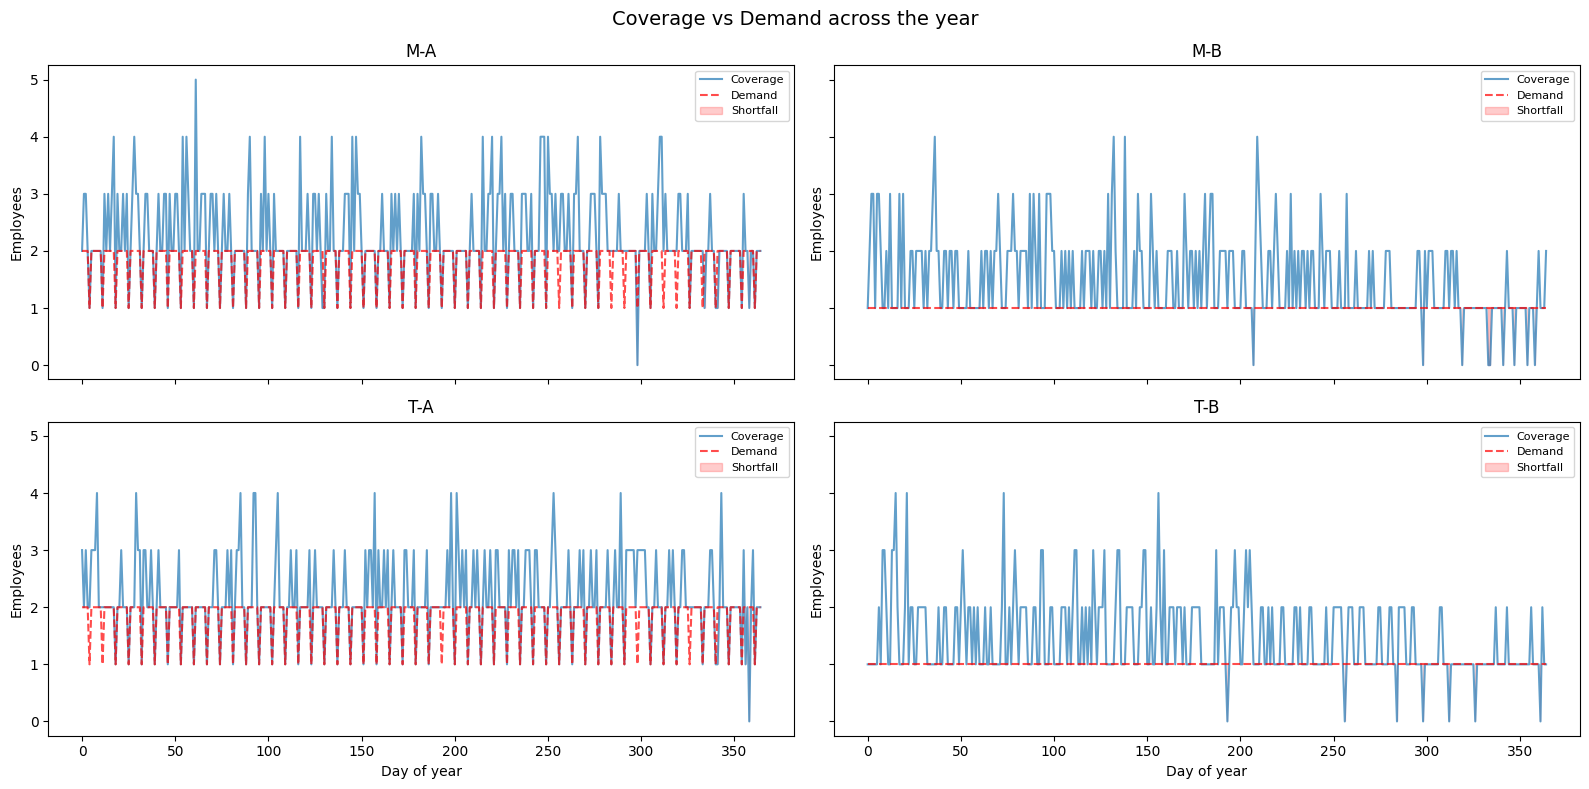


Quarter      M-A viol T-A viol M-B viol T-B viol  Total
----------------------------------------------------------
Q1 (  0- 91)         0        0        0        0      0
Q2 ( 91-182)         1        0        0        0      1
Q3 (182-273)         0        0        1        2      3
Q4 (273-365)         4        4        8        5     21
----------------------------------------------------------
Total                                                25

Days worked/employee: [223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223, 223]
Mean: 223.0, Min: 223, Max: 223


In [ ]:
import matplotlib.pyplot as plt

ckpt = torch.load("best_gnn_two_phase_v5.pth", weights_only=True)
model.load_state_dict(ckpt["model_state_dict"])
_, _, days_worked_list, _, snap = evaluate(model, env, graph, greedy=False)

days   = np.arange(env.num_days)
cov    = snap["daily_coverage"]   # (365, 2, 2)  — snapshot from this run
demand = env.min_demand            # (365, 2, 2)  — invariant

# Plot coverage vs demand for each shift-team
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)
shift_team = {(0,0): "M-A", (1,0): "T-A", (0,1): "M-B", (1,1): "T-B"}

for (s, t), name in shift_team.items():
    ax = axes[s][t]
    ax.plot(days, cov[:, s, t], label='Coverage', alpha=0.7)
    ax.plot(days, demand[:, s, t], label='Demand', alpha=0.7, linestyle='--', color='r')
    ax.fill_between(days, cov[:, s, t], demand[:, s, t],
                    where=cov[:, s, t] < demand[:, s, t],
                    color='red', alpha=0.2, label='Shortfall')
    ax.set_title(name)
    ax.set_ylabel('Employees')
    ax.legend(loc='upper right', fontsize=8)

axes[1][0].set_xlabel('Day of year')
axes[1][1].set_xlabel('Day of year')
fig.suptitle('Coverage vs Demand across the year', fontsize=14)
plt.tight_layout()
plt.show()

# Summary stats by quarter
print(f"\n{'Quarter':<12} {'M-A viol':>8} {'T-A viol':>8} {'M-B viol':>8} {'T-B viol':>8} {'Total':>6}")
print("-" * 58)
total_viol = 0
for q, (start, end) in enumerate([(0,91),(91,182),(182,273),(273,365)], 1):
    viols = {}
    q_total = 0
    for (s, t), name in shift_team.items():
        v = int(np.sum(np.maximum(0, demand[start:end, s, t] - cov[start:end, s, t])))
        viols[name] = v
        q_total += v
    total_viol += q_total
    print(f"Q{q} ({start:3d}-{end:3d})  {viols['M-A']:>8} {viols['T-A']:>8} {viols['M-B']:>8} {viols['T-B']:>8} {q_total:>6}")
print("-" * 58)
print(f"{'Total':<12} {'':>8} {'':>8} {'':>8} {'':>8} {total_viol:>6}")

days_worked_arr = np.array(days_worked_list)
print(f"\nDays worked/employee: {days_worked_list}")
print(f"Mean: {days_worked_arr.mean():.1f}, Min: {days_worked_arr.min()}, Max: {days_worked_arr.max()}")
